# NeuralODE / UDE Spectral Bias Analysis

Trains a Universal Differential Equation (UDE) on a forced first-order ODE.
The known dynamics (exponential decay) are provided; the network learns the
unknown multi-frequency forcing.  Spectral bias predicts low-frequency
components of the correction emerge before high-frequency ones.

In [3]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from argparse import Namespace
from scipy.integrate import solve_ivp

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.NeuralODE import NeuralODEFunc, compute_ude_correction
from src.spectral_analysis import compute_fft

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Figures -> /Users/marcogalliani/Projects/PINNs-and-spectral-bias/examples/spectral-analysis/figures


## ODE definition

In [4]:
class ForcedFirstOrderODE:
    def __init__(self, alpha, freqs, amps, phases):
        self.alpha  = alpha
        self.freqs  = list(freqs)
        self.amps   = list(amps)
        self.phases = list(phases)

    def _forcing(self, t, sin_fn):
        return sum(
            A * sin_fn(2 * np.pi * f * t + ph)
            for f, A, ph in zip(self.freqs, self.amps, self.phases)
        )

    def rhs_np(self, t, z):
        return [-self.alpha * z[0] + self._forcing(t, np.sin)]

    def known_rhs_torch(self, t, z):
        return -self.alpha * z

## Configuration

In [5]:
opt = Namespace()

opt.alpha  = 1.0
opt.freqs  = [1.0, 3.0, 5.0, 10.0]
opt.amps   = [1.0, 1.0, 1.0, 1.0]
opt.phases = [0.0, 0.0, 0.0, 0.0]
opt.y0     = [0.0]

opt.T        = 2.0
opt.N_POINTS = 500
opt.OBS_STEP = 4

opt.NUM_ITER        = 10_000
opt.REC_FRQ         = 200
opt.LR              = 1e-3
opt.LR_DECAY        = 0.9998
opt.NeuralODE_WIDTH = 256
opt.NeuralODE_DEPTH = 3

if torch.cuda.is_available():
    opt.DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    opt.DEVICE = torch.device("mps")
else:
    opt.DEVICE = torch.device("cpu")
print(f"Device: {opt.DEVICE}")

t_eval      = np.linspace(0, opt.T, opt.N_POINTS)
sample_rate = opt.N_POINTS / opt.T
ode = ForcedFirstOrderODE(opt.alpha, opt.freqs, opt.amps, opt.phases)

Device: mps


## Reference solution

In [6]:
u_true = np.array([
    sum(A * np.sin(2 * np.pi * f * t + ph)
        for f, A, ph in zip(opt.freqs, opt.amps, opt.phases))
    for t in t_eval
])

print("Reference (RK45)...")
sol   = solve_ivp(ode.rhs_np, [0, opt.T], opt.y0, t_eval=t_eval,
                  method="RK45", rtol=1e-9, atol=1e-11)
y_ref = sol.y.T

obs_idx = np.arange(0, opt.N_POINTS, opt.OBS_STEP)
t_obs   = t_eval[obs_idx]
y_obs   = y_ref[obs_idx]

Reference (RK45)...


## NeuralODE training

In [7]:
print(f"NeuralODE ({opt.NUM_ITER} iters, width={opt.NeuralODE_WIDTH}, "
      f"depth={opt.NeuralODE_DEPTH})...")
ude_func = NeuralODEFunc(
    n_vars=1, width=opt.NeuralODE_WIDTH, depth=opt.NeuralODE_DEPTH,
    known_rhs=ode.known_rhs_torch, zero_init=True,
).to(opt.DEVICE)

ude_frames = ude_func.fit(
    t_span=(0.0, opt.T), y0=opt.y0,
    t_obs_np=t_obs, y_obs_np=y_obs,
    n_iter=opt.NUM_ITER, lr=opt.LR, lr_decay=opt.LR_DECAY,
    rec_frq=opt.REC_FRQ, t_eval_np=t_eval,
    save_snapshots=True, verbose=True,
)

y_ude = ude_frames[-1].prediction

print("  Computing NeuralODE corrections...")
ude_corrections = compute_ude_correction(
    ude_frames, ude_func, t_eval, opt.y0, device=opt.DEVICE,
)

NeuralODE (10000 iters, width=256, depth=3)...
  iter      0 | loss 3.029e-02
  iter   2000 | loss 8.258e-04
  iter   4000 | loss 2.579e-04
  iter   6000 | loss 1.840e-04
  iter   8000 | loss 1.601e-04
  iter  10000 | loss 1.406e-04
  Computing NeuralODE corrections...


# UDE solution: time domain + spectrum

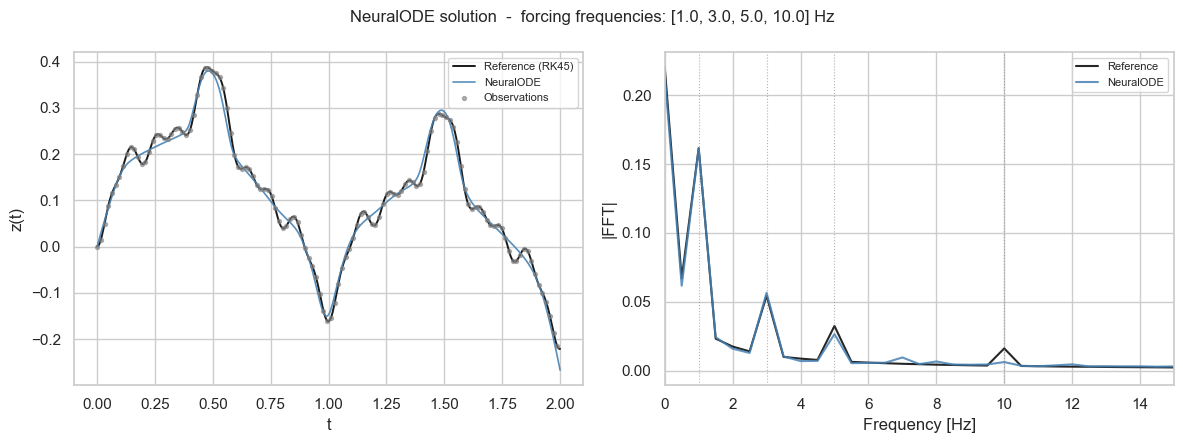

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"NeuralODE solution  -  forcing frequencies: {opt.freqs} Hz", fontsize=12)

axes[0].plot(t_eval, y_ref[:, 0], "k-", linewidth=1.4, label="Reference (RK45)")
axes[0].plot(t_eval, y_ude[:, 0], color="steelblue", linewidth=1.2, alpha=0.9, label="NeuralODE")
axes[0].scatter(t_obs, y_obs[:, 0], s=8, c="gray", alpha=0.6, zorder=3, label="Observations")
axes[0].set_xlabel("t")
axes[0].set_ylabel("z(t)")
axes[0].legend(fontsize=8)

for sol, lab, col in [(y_ref, "Reference", "black"), (y_ude, "NeuralODE", "steelblue")]:
    frqs, spec = compute_fft(sol[:, 0], sample_rate)
    axes[1].plot(frqs, spec, label=lab, color=col, alpha=0.85)
for f in opt.freqs:
    axes[1].axvline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
axes[1].set_xlim([0, max(opt.freqs) * 1.5])
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|FFT|")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ude_solution.png", dpi=150, bbox_inches="tight")
plt.show()

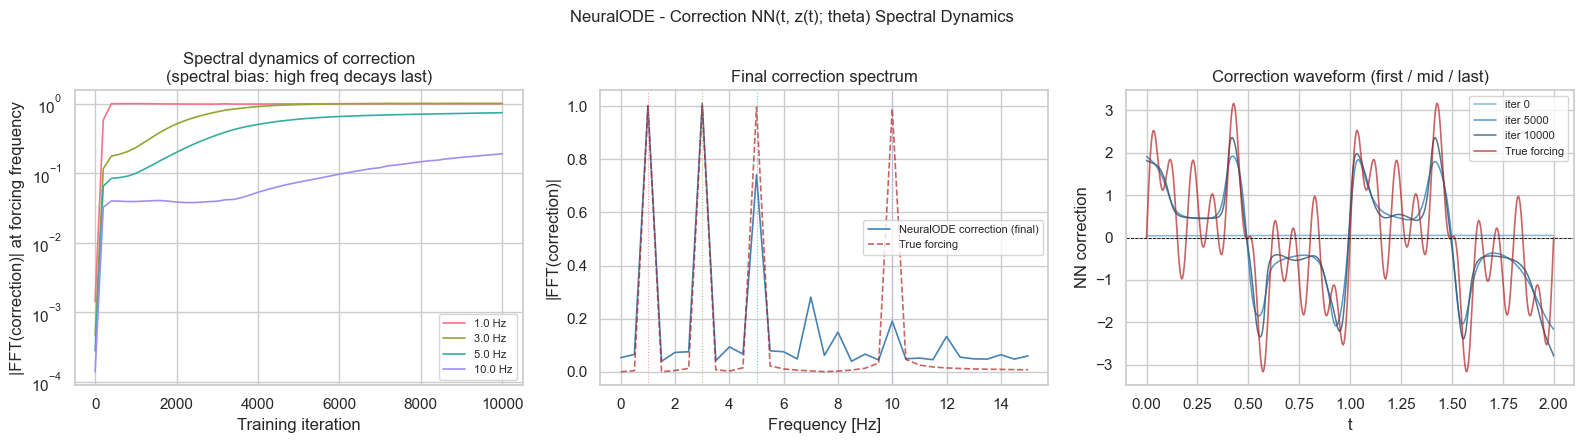

In [9]:
# NeuralODE correction spectral dynamics across training
valid       = [(f.iter_num, c) for f, c in zip(ude_frames, ude_corrections) if c is not None]
iters_c     = np.asarray([v[0] for v in valid])
corr_list   = [v[1] for v in valid]
palette     = sns.color_palette("husl", len(opt.freqs))
snap_idx    = [0, len(corr_list) // 2, len(corr_list) - 1]
snap_palette = sns.color_palette("Blues_d", len(snap_idx))

amp_curves = {f: [] for f in opt.freqs}
for c in corr_list:
    frqs_k, spec_k = compute_fft(c[:, 0], sample_rate)
    for f in opt.freqs:
        amp_curves[f].append(float(spec_k[np.argmin(np.abs(frqs_k - f))]))

frqs_final, spec_final = compute_fft(corr_list[-1][:, 0], sample_rate)
frqs_true_fft, spec_true_fft = compute_fft(u_true, sample_rate)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("NeuralODE - Correction NN(t, z(t); theta) Spectral Dynamics", fontsize=12)

ax = axes[0]
for f, col in zip(opt.freqs, palette):
    ax.plot(iters_c, amp_curves[f], label=f"{f} Hz", color=col, linewidth=1.2)
ax.set_xlabel("Training iteration")
ax.set_ylabel("|FFT(correction)| at forcing frequency")
ax.set_yscale("log")
ax.set_title("Spectral dynamics of correction\n(spectral bias: high freq decays last)")
ax.legend(fontsize=8)

ax = axes[1]
mask = frqs_final <= max(opt.freqs) * 1.5
ax.plot(frqs_final[mask], spec_final[mask], color="steelblue", linewidth=1.2,
        label="NeuralODE correction (final)")
ax.plot(frqs_true_fft[mask], spec_true_fft[mask], color="firebrick", linewidth=1.2,
        alpha=0.7, linestyle="--", label="True forcing")
for f, col in zip(opt.freqs, palette):
    ax.axvline(f, color=col, linestyle=":", linewidth=0.8, alpha=0.7)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("|FFT(correction)|")
ax.set_title("Final correction spectrum")
ax.legend(fontsize=8)

ax = axes[2]
for idx, col in zip(snap_idx, snap_palette):
    ax.plot(t_eval, corr_list[idx][:, 0], color=col, alpha=0.85,
            linewidth=1.1, label=f"iter {iters_c[idx]}")
ax.plot(t_eval, u_true, color="firebrick", linewidth=1.2, alpha=0.7, label="True forcing")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_xlabel("t")
ax.set_ylabel("NN correction")
ax.set_title("Correction waveform (first / mid / last)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ude_correction_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()